,dataset,model,approach,comparison,n_repetitions
0,cifar10,cnn,fl,cnn | fl,10
1,cifar10,resnet,fl,resnet | fl,10
2,cifar10,vgg16,fl,vgg16 | fl,4
3,mnist,cnn,fl,cnn | fl,10
4,mnist,resnet,fl,resnet | fl,10
5,mnist,vgg16,fl,vgg16 | fl,10


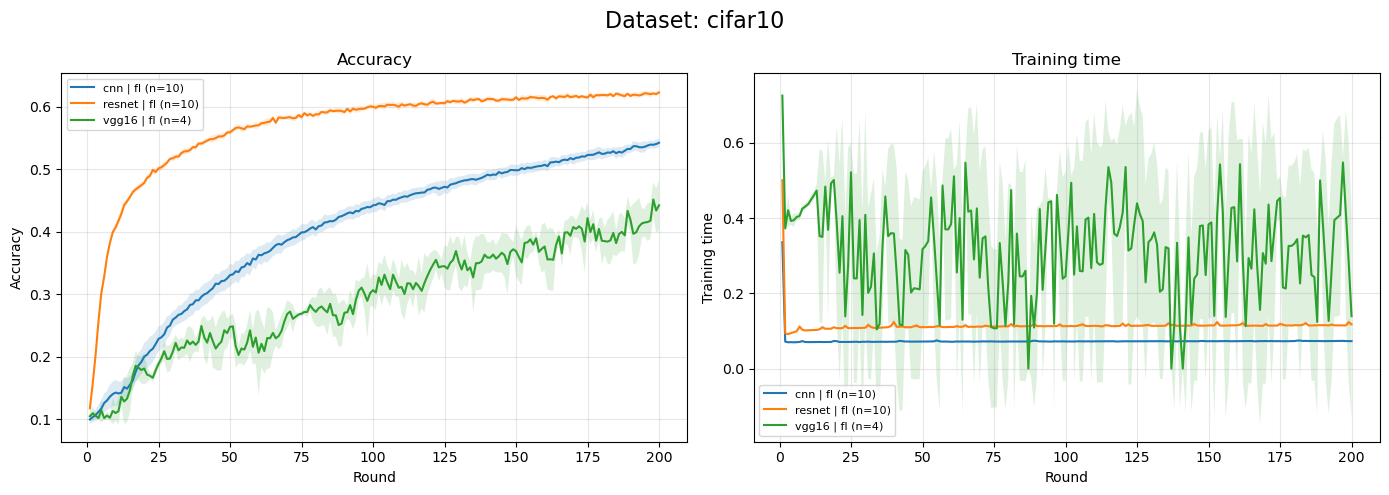

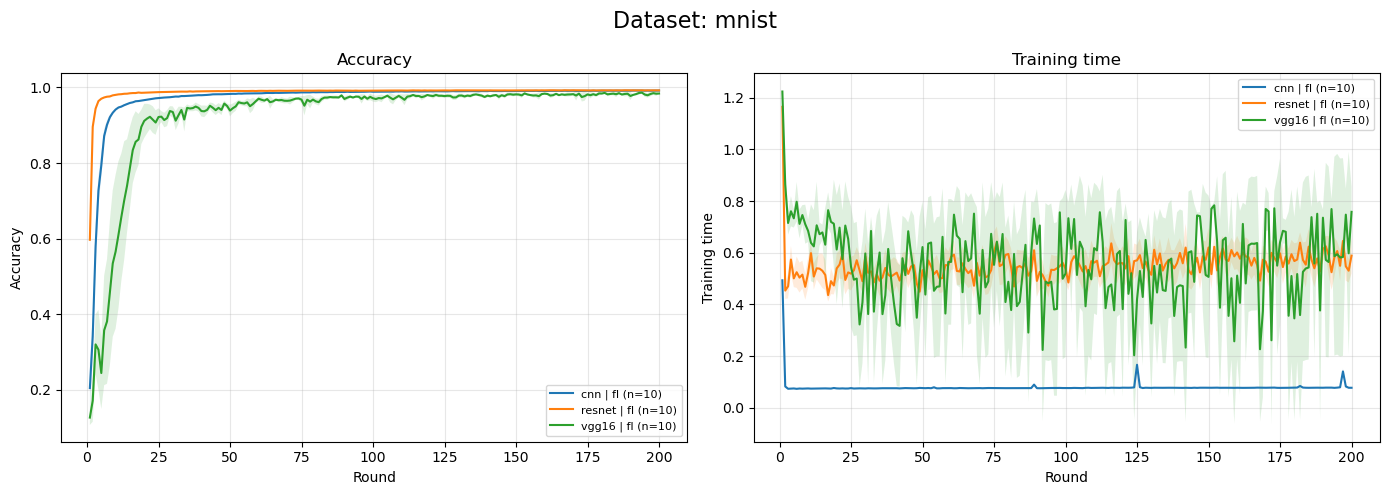

In [4]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
CONFIDENCE_Z = 1.96

def normalize_name(value):
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9]+", "_", value)
    value = re.sub(r"_+", "_", value)
    return value.strip("_")

def find_column(columns, candidates):
    normalized = {normalize_name(c): c for c in columns}
    for candidate in candidates:
        candidate = normalize_name(candidate)
        if candidate in normalized:
            return normalized[candidate]
    for candidate in candidates:
        candidate = normalize_name(candidate)
        for key, original in normalized.items():
            if candidate in key:
                return original
    return None

def infer_metadata(path):
    relative = path.relative_to(DATA_DIR)
    parts = list(relative.parts[:-1])
    stem = path.stem
    text = "_".join(parts + [stem]).lower()
    tokens = [t for t in re.split(r"[^a-z0-9]+", text) if t]

    known_datasets = ["mnist", "cifar10", "cifar100", "fashionmnist", "femnist"]
    known_models = ["vgg16", "resnet18", "resnet50", "cnn", "mlp", "mobilenet", "alexnet"]

    dataset = next((x for x in known_datasets if x in tokens or x in text), None)
    model = next((x for x in known_models if x in tokens or x in text), None)

    if dataset is None:
        dataset = parts[0] if len(parts) > 0 else "unknown_dataset"

    if model is None:
        model = parts[1] if len(parts) > 1 else "unknown_model"

    if len(parts) > 2:
        approach = parts[2]
    else:
        cleaned = stem
        for value in [dataset, model]:
            cleaned = re.sub(value, "", cleaned, flags=re.IGNORECASE)
        cleaned = re.sub(r"(run|rep|repeat|seed)[_\- ]?\d+", "", cleaned, flags=re.IGNORECASE)
        cleaned = re.sub(r"\d+", "", cleaned)
        cleaned = re.sub(r"[^a-zA-Z0-9]+", "_", cleaned).strip("_")
        approach = cleaned if cleaned else "unknown_approach"

    repetition_match = re.search(r"(?:run|rep|repeat|seed)[_\- ]?(\d+)", stem.lower())
    repetition = repetition_match.group(1) if repetition_match else stem

    return dataset, model, approach, repetition

def load_one_csv(path):
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]

    round_col = find_column(df.columns, ["round", "rounds", "server_round", "epoch"])
    accuracy_col = find_column(df.columns, ["accuracy", "acc", "test_accuracy", "val_accuracy"])
    training_col = find_column(df.columns, ["training_time", "train_time", "fit_time", "local_training_time"])
    total_col = find_column(df.columns, ["total_runtime", "total_round_time", "round_time", "runtime", "total_time"])

    dataset_col = find_column(df.columns, ["dataset"])
    model_col = find_column(df.columns, ["model"])
    approach_col = find_column(df.columns, ["approach", "strategy", "algorithm", "method", "technique"])

    dataset, model, approach, repetition = infer_metadata(path)

    out = pd.DataFrame()
    out["round"] = pd.to_numeric(df[round_col], errors="coerce") if round_col else np.arange(1, len(df) + 1)
    out["dataset"] = df[dataset_col].astype(str) if dataset_col else dataset
    out["model"] = df[model_col].astype(str) if model_col else model
    out["approach"] = df[approach_col].astype(str) if approach_col else approach
    out["repetition"] = repetition
    out["source_file"] = str(path)

    out["accuracy"] = pd.to_numeric(df[accuracy_col], errors="coerce") if accuracy_col else np.nan
    out["training_time"] = pd.to_numeric(df[training_col], errors="coerce") if training_col else np.nan
    out["total_runtime"] = pd.to_numeric(df[total_col], errors="coerce") if total_col else np.nan

    out = out.dropna(subset=["round"])
    out["round"] = out["round"].astype(int)

    return out

csv_files = sorted(DATA_DIR.rglob("*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(f"Nessun CSV trovato in {DATA_DIR.resolve()}")

data = pd.concat([load_one_csv(path) for path in csv_files], ignore_index=True)

for column in ["dataset", "model", "approach"]:
    data[column] = data[column].astype(str)

data["run_id"] = data["source_file"].astype(str)
data["comparison"] = data["model"] + " | " + data["approach"]

metrics = {
    "accuracy": "Accuracy",
    "training_time": "Training time",
    "total_runtime": "Total runtime"
}

data = data.dropna(subset=list(metrics.keys()), how="all")

repetition_counts = (
    data[["dataset", "model", "approach", "comparison", "run_id"]]
    .drop_duplicates()
    .groupby(["dataset", "model", "approach", "comparison"])
    .size()
    .rename("n_repetitions")
    .reset_index()
)

summary = (
    data
    .groupby(["dataset", "model", "approach", "comparison", "round"], as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        accuracy_n=("accuracy", "count"),
        training_time_mean=("training_time", "mean"),
        training_time_std=("training_time", "std"),
        training_time_n=("training_time", "count"),
        total_runtime_mean=("total_runtime", "mean"),
        total_runtime_std=("total_runtime", "std"),
        total_runtime_n=("total_runtime", "count")
    )
)

summary = summary.merge(
    repetition_counts,
    on=["dataset", "model", "approach", "comparison"],
    how="left"
)

for metric in metrics:
    summary[f"{metric}_sem"] = summary[f"{metric}_std"] / np.sqrt(summary[f"{metric}_n"])
    summary[f"{metric}_ci"] = CONFIDENCE_Z * summary[f"{metric}_sem"]
    summary[f"{metric}_ci"] = summary[f"{metric}_ci"].fillna(0)

display(repetition_counts.sort_values(["dataset", "model", "approach"]).reset_index(drop=True))

for dataset, dataset_group in summary.groupby("dataset"):
    available_metrics = [
        metric for metric in metrics
        if dataset_group[f"{metric}_mean"].notna().any()
    ]

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(available_metrics),
        figsize=(7 * len(available_metrics), 5),
        squeeze=False
    )

    for col_index, metric in enumerate(available_metrics):
        ax = axes[0][col_index]

        for comparison, comparison_group in dataset_group.groupby("comparison"):
            comparison_group = comparison_group.sort_values("round")

            if not comparison_group[f"{metric}_mean"].notna().any():
                continue

            x = comparison_group["round"].to_numpy()
            y = comparison_group[f"{metric}_mean"].to_numpy()
            ci = comparison_group[f"{metric}_ci"].to_numpy()
            n_repetitions = int(comparison_group["n_repetitions"].max())

            ax.plot(x, y, label=f"{comparison} (n={n_repetitions})")
            ax.fill_between(x, y - ci, y + ci, alpha=0.15)

        ax.set_title(metrics[metric])
        ax.set_xlabel("Round")
        ax.set_ylabel(metrics[metric])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle(f"Dataset: {dataset}", fontsize=16)
    fig.tight_layout()
    plt.show()